In [1]:
!pip install plotly --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 50.4 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.metrics import precision_recall_curve

# **rodar**

In [3]:
base_credit = pd.read_csv("/content/creditcard.csv")

In [4]:
base_credit


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45641,42436,-2.481639,-2.439949,0.363642,1.216827,2.572442,-1.264220,-0.443652,0.075853,0.073188,...,-0.039426,0.480591,1.779358,-0.756700,-0.161099,0.685617,0.223071,0.139619,0.00,0.0
45642,42436,1.223475,0.014944,0.471312,-0.038410,-0.566793,-0.867970,-0.058213,-0.144080,0.164904,...,-0.053292,-0.093680,0.106348,0.471407,0.135555,0.968336,-0.065171,0.005184,7.49,0.0
45643,42436,1.258657,0.421016,0.325437,0.684259,-0.292529,-1.052786,0.145228,-0.253567,-0.100521,...,-0.278029,-0.757417,0.119613,0.369393,0.246145,0.091553,-0.017156,0.032557,0.89,0.0
45644,42437,-0.500147,1.000770,1.809639,-0.114551,0.333865,-0.577076,1.062325,-0.513050,-0.048285,...,-0.193814,-0.161410,0.036965,0.400154,-0.802486,-0.076097,-0.214317,-0.229160,2.69,0.0


Análise de colunas no geral

In [5]:
base_credit.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,45646.000000,45646.000000,45646.000000,45646.000000,45646.000000,45646.000000,45645.000000,45645.000000,45645.000000,45645.000000,...,45645.000000,45645.000000,45645.000000,45645.000000,45645.000000,45645.000000,45645.000000,45645.000000,45645.000000,45645.000000
mean,27545.441331,-0.237544,0.028942,0.696718,0.191505,-0.248407,0.098588,-0.117937,0.053331,0.157893,...,-0.027098,-0.108684,-0.039060,0.009358,0.136697,0.022305,0.005524,0.004641,90.829574,0.003111
std,12907.770469,1.886548,1.613070,1.530553,1.403936,1.414608,1.308548,1.282818,1.210502,1.222268,...,0.733323,0.636670,0.572037,0.592176,0.437824,0.502716,0.389241,0.338798,240.298594,0.055690
min,0.000000,-56.407510,-72.715728,-32.965346,-5.172595,-42.147898,-26.160506,-26.548144,-41.484823,-9.283925,...,-20.262054,-8.593642,-26.751119,-2.836627,-7.495741,-1.438650,-8.567638,-9.617915,0.000000,0.000000
25%,19891.000000,-0.985248,-0.543868,0.222804,-0.714566,-0.853436,-0.638480,-0.600071,-0.148358,-0.589301,...,-0.232743,-0.529609,-0.179136,-0.322003,-0.128065,-0.329709,-0.063670,-0.006837,7.580000,0.000000
50%,32447.000000,-0.246259,0.088873,0.801638,0.191835,-0.280620,-0.155353,-0.073143,0.054815,0.038334,...,-0.070241,-0.083448,-0.051304,0.062230,0.175771,-0.067778,0.008425,0.021814,24.990000,0.000000
75%,37571.750000,1.157412,0.739723,1.434911,1.070924,0.287608,0.487645,0.429944,0.324345,0.859738,...,0.105614,0.303459,0.077905,0.401392,0.421857,0.302819,0.084017,0.076209,82.600000,0.000000
max,42437.000000,1.960497,18.183626,4.101716,16.491217,34.801666,22.529298,36.677268,20.007208,10.392889,...,22.614889,5.805795,17.297845,4.014444,5.525093,3.517346,11.135740,33.847808,7879.420000,1.000000


Análise da coluna Class

In [6]:
base_credit["Class"]

,Class
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
45641,0.0
45642,0.0
45643,0.0
45644,0.0


In [7]:
base_credit["Class"].isnull().any()

np.True_

In [8]:
base_credit["Class"].isnull().sum()

np.int64(1)

In [9]:
base_credit["Class"].isnull().mean() * 100

np.float64(0.002190772466371643)

In [10]:
base_credit[base_credit["Class"].isnull()]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
45645,42437,-0.652459,0.17729,1.955607,-1.879724,-0.368457,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Análise da coluna Amount

Text(0, 0.5, 'Frequência (Log)')

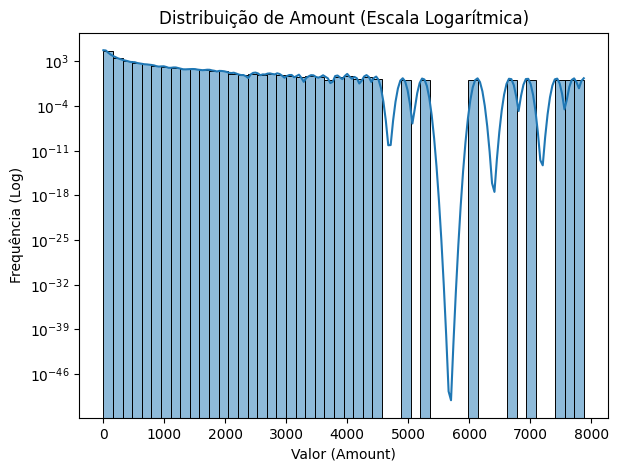

In [11]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(base_credit['Amount'], bins=50, kde=True)
plt.yscale('log')
plt.title('Distribuição de Amount (Escala Logarítmica)')
plt.xlabel('Valor (Amount)')
plt.ylabel('Frequência (Log)')

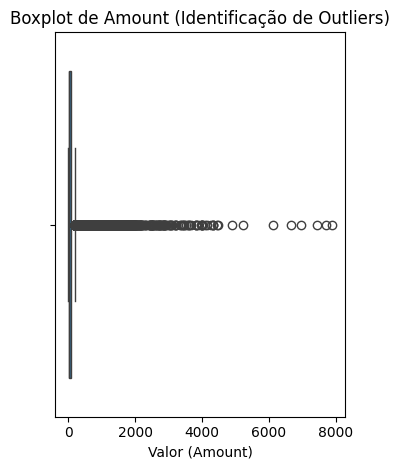

In [12]:
plt.subplot(1, 2, 2)
sns.boxplot(x=base_credit['Amount'])
plt.title('Boxplot de Amount (Identificação de Outliers)')
plt.xlabel('Valor (Amount)')

plt.tight_layout()
plt.show()

Normalização da coluna Amount

In [13]:
base_credit["Amount"] = StandardScaler().fit_transform(base_credit["Amount"].values.reshape(-1,1))

Drop da coluna Time

In [14]:
base_credit = base_credit.drop(["Time"], axis=1)

In [15]:
base_credit

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244658,0.0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.366796,0.0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.197816,0.0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.135959,0.0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.086725,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45641,-2.481639,-2.439949,0.363642,1.216827,2.572442,-1.264220,-0.443652,0.075853,0.073188,0.097421,...,-0.039426,0.480591,1.779358,-0.756700,-0.161099,0.685617,0.223071,0.139619,-0.377990,0.0
45642,1.223475,0.014944,0.471312,-0.038410,-0.566793,-0.867970,-0.058213,-0.144080,0.164904,-0.248839,...,-0.053292,-0.093680,0.106348,0.471407,0.135555,0.968336,-0.065171,0.005184,-0.346821,0.0
45643,1.258657,0.421016,0.325437,0.684259,-0.292529,-1.052786,0.145228,-0.253567,-0.100521,-0.308072,...,-0.278029,-0.757417,0.119613,0.369393,0.246145,0.091553,-0.017156,0.032557,-0.374287,0.0
45644,-0.500147,1.000770,1.809639,-0.114551,0.333865,-0.577076,1.062325,-0.513050,-0.048285,0.314582,...,-0.193814,-0.161410,0.036965,0.400154,-0.802486,-0.076097,-0.214317,-0.229160,-0.366796,0.0


Divisão entre dados normais e dados de fraude

In [16]:
date_normal = base_credit[base_credit["Class"] == 0]

In [17]:
date_fraud = base_credit[base_credit["Class"] == 1]

Retirando a coluna Class, pois o modelo não pode saber do rótulo

In [18]:
x = date_normal.drop(["Class"], axis=1).values

In [19]:
y = date_fraud.drop(["Class"], axis=1).values

In [20]:
X_treino, X_teste = train_test_split(x, test_size=0.2, random_state=42)

Iniciação do processo de arquitetura do autoencoder

In [21]:
input_dim = X_treino.shape[1]

In [22]:
input_layer = Input(shape=(input_dim,))

Encoder (entrada)

In [23]:
encoder = Dense(14, activation="relu")(input_layer)

In [24]:
encoder = Dense(7, activation="relu")(encoder)

Decoder (saida)

In [25]:
decoder = Dense(14, activation="relu")(encoder)

In [26]:
decoder = Dense(input_dim, activation="linear")(decoder)

In [27]:
autoencoder = Model(inputs=input_layer, outputs=decoder)

In [28]:
autoencoder.compile(optimizer='adam', loss='mse')

Treinamento das Redes Neurais

In [29]:
treinamento = autoencoder.fit(
    X_treino, X_treino,
    epochs=50,
    batch_size=32,
    shuffle=True,
    validation_data=(X_teste, X_teste),
    verbose=1
).history

Epoch 1/50
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.7431 - val_loss: 0.5659
Epoch 2/50
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5021 - val_loss: 0.4772
Epoch 3/50
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4340 - val_loss: 0.4272
Epoch 4/50
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3980 - val_loss: 0.3995
Epoch 5/50
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.3753 - val_loss: 0.3784
Epoch 6/50
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3525 - val_loss: 0.3610
Epoch 7/50
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3392 - val_loss: 0.3487
Epoch 8/50
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3316 - val_loss: 0.3456
Epoch 9/50
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3255 - val_loss: 0.3373
Epoch 10/50
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3208 - val_loss: 0.3373
Epoch 11/50
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3157 - val_loss: 0.3339
Epoch 12/50
1138/1138 ━━━━━━━━

In [30]:
reconstrucao_normal = autoencoder.predict(X_teste)

285/285 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [31]:
reconstrucao_fraude = autoencoder.predict(y)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [32]:
normal_mse = np.mean(np.power(X_teste - reconstrucao_normal, 2), axis = 1)

In [33]:
fraude_mse = np.mean(np.power(y - reconstrucao_fraude, 2), axis = 1)

In [34]:
print(f"Erro médio que acontece em transações normais: {normal_mse.mean():.4f}")

Erro médio que acontece em transações normais: 0.2944


In [35]:
print(f"Erro médio que aconteceu em transações fraudulentas: {fraude_mse.mean():.4f}")

Erro médio que aconteceu em transações fraudulentas: 3.3739


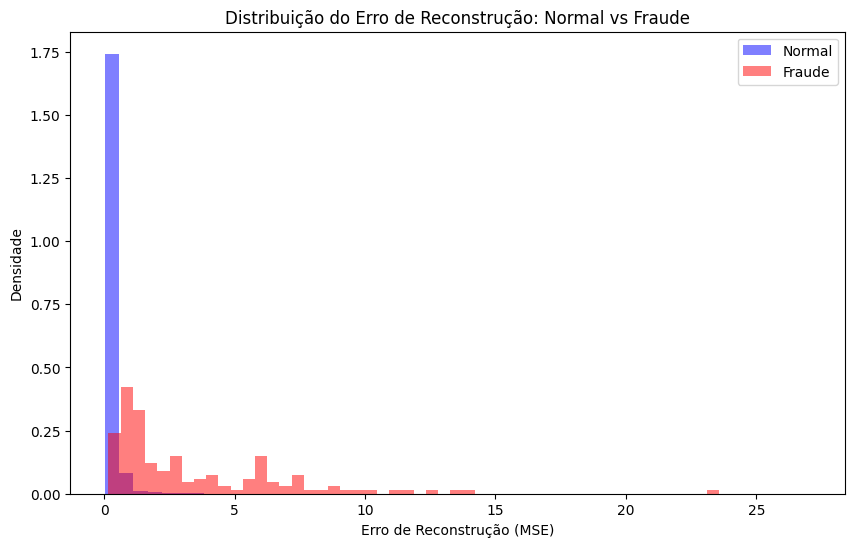

In [36]:
plt.figure(figsize=(10, 6))


plt.hist(normal_mse, bins=50, alpha=0.5, label='Normal', color='blue', density=True)


plt.hist(fraude_mse, bins=50, alpha=0.5, label='Fraude', color='red', density=True)

plt.title('Distribuição do Erro de Reconstrução: Normal vs Fraude')
plt.xlabel('Erro de Reconstrução (MSE)')
plt.ylabel('Densidade')
plt.legend()
plt.show()

In [37]:
y_verdadeiro = [0] * len(normal_mse) + [1] * len(fraude_mse)

In [38]:
todos_os_erros = np.concatenate([normal_mse, fraude_mse])

In [43]:
precision, recall, thresholds = precision_recall_curve(y_verdadeiro, todos_os_erros)

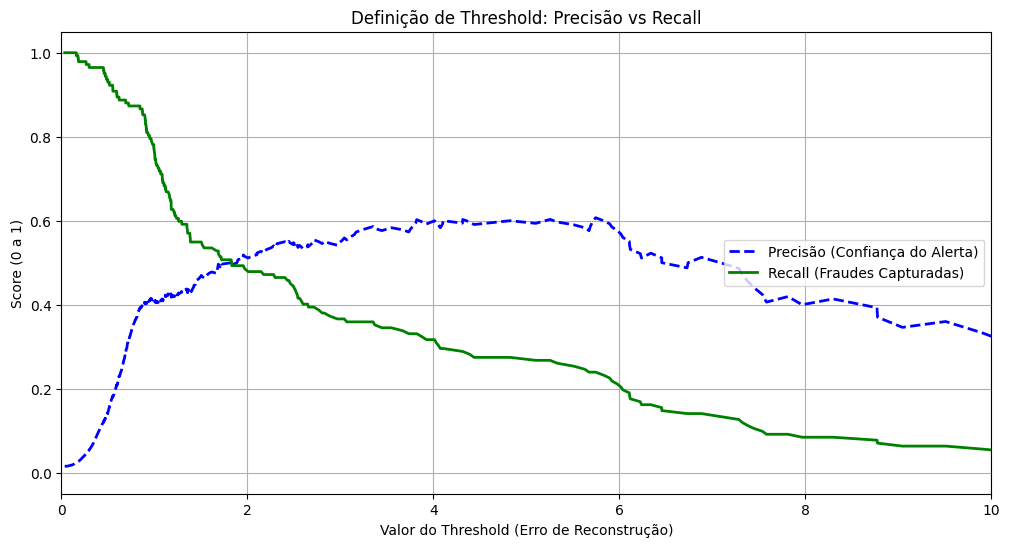

In [48]:
plt.figure(figsize=(12, 6))

plt.plot(thresholds, precision[:-1], "b--", label="Precisão (Confiança do Alerta)", lw=2)
plt.plot(thresholds, recall[:-1], "g-", label="Recall (Fraudes Capturadas)", lw=2)

plt.title('Definição de Threshold: Precisão vs Recall')
plt.xlabel('Valor do Threshold (Erro de Reconstrução)')
plt.ylabel('Score (0 a 1)')
plt.legend(loc="center right")
plt.grid(True)

plt.xlim([0, 10])
plt.show()

In [49]:
thresholds = 1.8

In [50]:
classe_teste = [1 if e > thresholds else 0 for e in normal_mse]

In [51]:
classe_fraude = [1 if e > thresholds else 0 for e in fraude_mse]

In [54]:
fraudes_totais = len(fraude_mse)

In [55]:
deteccao_fraud = sum(classe_fraude)

In [56]:
falsa_deteccao = sum(classe_teste)

In [59]:
print("Resultado: ")

Resultado: 


In [60]:
print(f"(Definição do Threshould: {thresholds})")

(Definição do Threshould: 1.8)


In [61]:
print(f"Fraudes detectadas: {deteccao_fraud}, de um total de: {fraudes_totais}, ({(deteccao_fraud / fraudes_totais) * 100:.1f})")

Fraudes detectadas: 72, de um total de: 142, (50.7)


In [62]:
print(f"Desvio de cliente: {falsa_deteccao}")

Desvio de cliente: 72
